In [1]:
import os
print(os.listdir())


['.ipynb_checkpoints', 'Task2_Sentiment.ipynb', 'Tweets.csv']


In [2]:
import pandas as pd

df = pd.read_csv("Tweets.csv")
df = df[["text", "airline_sentiment"]]

print(df.shape)
print(df["airline_sentiment"].value_counts())
df.head()

(14640, 2)
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [3]:
df["airline_sentiment"].value_counts(normalize=True)

airline_sentiment
negative    0.626913
neutral     0.211680
positive    0.161407
Name: proportion, dtype: float64

In [4]:
import re

def clean_text(text):
    text = text.lower()                      # lowercase everything
    text = re.sub(r"http\S+", "", text)      # remove links
    text = re.sub(r"@\w+", "", text)         # remove @mentions
    text = re.sub(r"[^a-z\s]", "", text)     # keep only letters and spaces
    text = re.sub(r"\s+", " ", text).strip() # tidy up extra spaces
    return text

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["airline_sentiment"],
    test_size=0.2, random_state=42, stratify=df["airline_sentiment"]
)

print("Training tweets:", len(X_train))
print("Test tweets:", len(X_test))

Training tweets: 11712
Test tweets: 2928


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Training matrix shape:", X_train_vec.shape)

Training matrix shape: (11712, 5000)


In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

from sklearn.metrics import accuracy_score
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

Accuracy: 0.7691


In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.79      0.94      0.86      1835
     neutral       0.63      0.42      0.50       620
    positive       0.82      0.56      0.66       473

    accuracy                           0.77      2928
   macro avg       0.74      0.64      0.68      2928
weighted avg       0.76      0.77      0.75      2928



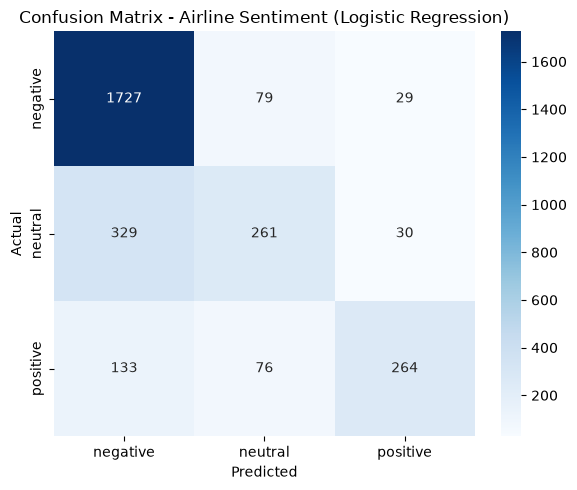

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = ["negative", "neutral", "positive"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Airline Sentiment (Logistic Regression)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [10]:
model_bal = LogisticRegression(max_iter=1000, class_weight="balanced")
model_bal.fit(X_train_vec, y_train)

y_pred_bal = model_bal.predict(X_test_vec)

print("Accuracy:", round(accuracy_score(y_test, y_pred_bal), 4))
print(classification_report(y_test, y_pred_bal))

Accuracy: 0.7425
              precision    recall  f1-score   support

    negative       0.89      0.77      0.83      1835
     neutral       0.51      0.69      0.58       620
    positive       0.68      0.68      0.68       473

    accuracy                           0.74      2928
   macro avg       0.69      0.72      0.70      2928
weighted avg       0.77      0.74      0.75      2928



In [11]:
samples = [
    "Amazing crew, the flight was smooth and on time!",
    "Worst airline ever, my bag was lost and nobody helped.",
    "Flight departs at 6pm from gate 12.",
    "Thanks for the upgrade, really appreciate it",
    "Delayed again, three hours waiting at the gate"
]

samples_clean = [clean_text(s) for s in samples]
samples_vec = vectorizer.transform(samples_clean)

pred_orig = model.predict(samples_vec)
pred_bal = model_bal.predict(samples_vec)

for text, p1, p2 in zip(samples, pred_orig, pred_bal):
    print(f"{text}\n   original: {p1} | balanced: {p2}\n")

Amazing crew, the flight was smooth and on time!
   original: positive | balanced: positive

Worst airline ever, my bag was lost and nobody helped.
   original: negative | balanced: negative

Flight departs at 6pm from gate 12.
   original: negative | balanced: negative

Thanks for the upgrade, really appreciate it
   original: positive | balanced: positive

Delayed again, three hours waiting at the gate
   original: negative | balanced: negative



In [12]:
import joblib

joblib.dump(model_bal, "sentiment_model.joblib")
joblib.dump(vectorizer, "sentiment_vectorizer.joblib")
print("Saved!")

Saved!


## Task 2 Summary: Airline Tweet Sentiment Analysis

**Dataset:** I used the Twitter US Airline Sentiment dataset (Figure Eight) from Kaggle, which contains 14,640 tweets labelled positive, negative or neutral. The classes are imbalanced: negative 62.7% (9,178), neutral 21.2% (3,099) and positive 16.1% (2,363). This means a model that always predicts "negative" would already reach about 63% accuracy, so that was the baseline to beat.

**Preprocessing:** I cleaned the text by lowercasing it and removing links, @mentions, punctuation and extra spaces. I then split the data 80/20 (11,712 training and 2,928 test tweets), stratified so every class keeps the same proportion in both sets. For vectorization I used TF-IDF with English stopword removal, the 5,000 most useful features, and both single words and word pairs (unigrams and bigrams). The vectorizer was fitted on the training data only, to avoid data leakage.

**Model:** I trained a Logistic Regression classifier, a fast and interpretable baseline that works well with TF-IDF features. I trained two versions: a standard model and one with class_weight="balanced" to compensate for the imbalance.

**Results:**

| Metric | Standard model | Balanced model |
|---|---|---|
| Accuracy | 76.91% | 74.25% |
| Recall (negative) | 0.94 | 0.77 |
| Recall (neutral) | 0.42 | 0.69 |
| Recall (positive) | 0.56 | 0.68 |
| Macro F1 | 0.68 | 0.70 |

The standard model has the higher accuracy, but it achieves it by favouring the majority class: it misclassified 329 of 620 neutral tweets as negative. The balanced model gives up about 2.7 points of accuracy but is much fairer across the three classes, with neutral recall rising from 0.42 to 0.69 and macro F1 improving. I therefore chose the balanced model as the final one, because catching all three sentiments matters more than raw accuracy on this data.

**Limitations:**
1. **Class imbalance:** The dataset is dominated by negative tweets, so the standard model is biased towards predicting negative. Class weighting reduced this but did not remove it, and neutral precision dropped to 0.51.
2. **No understanding of context:** TF-IDF only counts words. When I tested my own tweets, the factual statement "Flight departs at 6pm from gate 12." was classified as negative by both models, because words like "flight" and "gate" appear mostly in complaints in this dataset. The model also cannot handle sarcasm.
3. **Narrow domain:** The model was trained only on airline tweets, so it may perform poorly on other kinds of text such as product or movie reviews.

**Possible improvements:** Collecting more neutral and positive examples, or using a transformer-based model such as BERT that understands context, would likely give better results.